In [81]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [18]:
df=pd.read_excel("/content/new_cardekho_dataset.xlsx")
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0.0,Maruti Alto,Maruti,Alto,9,120000.0,Individual,Petrol,Manual,19.70,796.0,46.30,5,120000.0
1,1.0,Hyundai Grand,Hyundai,Grand,5,20000.0,Individual,Petrol,Manual,18.90,1197.0,82.00,5,550000.0
2,2.0,Hyundai i20,Hyundai,i20,11,60000.0,Individual,Petrol,Manual,17.00,1197.0,80.00,5,215000.0
3,3.0,Maruti Alto,Maruti,Alto,9,37000.0,Individual,Petrol,Manual,20.92,998.0,67.10,5,226000.0
4,4.0,Ford Ecosport,Ford,Ecosport,6,30000.0,Dealer,Diesel,Manual,22.77,1498.0,98.59,5,570000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1392,NaN,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,6,56000.0,Dealer,Diesel,Automatic,13.50,2987.0,254.79,5,4500000.0
1393,NaN,Maruti Swift,Maruti,Swift,14,187500.0,Individual,Diesel,Manual,17.80,1248.0,75.00,5,215000.0
1394,NaN,Hyundai i20,Hyundai,i20,7,67000.0,Dealer,Diesel,Manual,21.90,1396.0,90.00,5,355000.0
1395,NaN,Maruti Swift,Maruti,Swift,6,38000.0,Individual,Diesel,Manual,NaN,1248.0,74.00,5,530000.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1383 non-null   float64
 1   car_name           1397 non-null   object 
 2   brand              1397 non-null   object 
 3   model              1397 non-null   object 
 4   vehicle_age        1397 non-null   int64  
 5   km_driven          1384 non-null   float64
 6   seller_type        1397 non-null   object 
 7   fuel_type          1397 non-null   object 
 8   transmission_type  1397 non-null   object 
 9   mileage            1381 non-null   float64
 10  engine             1390 non-null   float64
 11  max_power          1388 non-null   float64
 12  seats              1397 non-null   int64  
 13  selling_price      1395 non-null   float64
dtypes: float64(6), int64(2), object(6)
memory usage: 152.9+ KB


In [20]:
df.isnull().sum()

,0
Unnamed: 0,14
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,13
seller_type,0
fuel_type,0
transmission_type,0
mileage,16


In [36]:
df['km_driven']=df['km_driven'].fillna(df['km_driven'].mean())

In [23]:
df['mileage']=df['mileage'].fillna(df['mileage'].mean())
df['max_power']=df['max_power'].fillna(df['max_power'].mean())
df['engine']=df['engine'].fillna(df['engine'].mode())
df['seats']=df['seats'].fillna(df['seats'].mode())

In [42]:
df['selling_price']=df['selling_price'].fillna(df['selling_price'].mean())

In [47]:
df['engine']=df['engine'].fillna(df['engine'].median())

In [55]:
df.isnull().sum().sum()

np.int64(0)

In [57]:
df.duplicated().sum()

np.int64(0)

In [59]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['transmission_type']=le.fit_transform(df['transmission_type'])


In [ ]:
from sklearn.preprocessing import OneHotEncoder

One = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse_output=False makes it return a dense array
fuel_type_encoded = One.fit_transform(df[['fuel_type']])

fuel_type_cols = One.get_feature_names_out(['fuel_type'])

fuel_type_df = pd.DataFrame(fuel_type_encoded, columns=fuel_type_cols, index=df.index)

df = pd.concat([df.drop('fuel_type', axis=1), fuel_type_df], axis=1)

In [64]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,transmission_type,mileage,engine,max_power,seats,selling_price,unnamed,fuel_type_CNG,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol
0,Maruti Alto,Maruti,Alto,9,120000.0,Individual,1,19.700000,796.0,46.30,5,120000.0,1.0,0.0,0.0,0.0,1.0
1,Hyundai Grand,Hyundai,Grand,5,20000.0,Individual,1,18.900000,1197.0,82.00,5,550000.0,2.0,0.0,0.0,0.0,1.0
2,Hyundai i20,Hyundai,i20,11,60000.0,Individual,1,17.000000,1197.0,80.00,5,215000.0,3.0,0.0,0.0,0.0,1.0
3,Maruti Alto,Maruti,Alto,9,37000.0,Individual,1,20.920000,998.0,67.10,5,226000.0,4.0,0.0,0.0,0.0,1.0
4,Ford Ecosport,Ford,Ecosport,6,30000.0,Dealer,1,22.770000,1498.0,98.59,5,570000.0,5.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1392,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,6,56000.0,Dealer,0,13.500000,2987.0,254.79,5,4500000.0,1393.0,0.0,1.0,0.0,0.0
1393,Maruti Swift,Maruti,Swift,14,187500.0,Individual,1,17.800000,1248.0,75.00,5,215000.0,1394.0,0.0,1.0,0.0,0.0
1394,Hyundai i20,Hyundai,i20,7,67000.0,Dealer,1,21.900000,1396.0,90.00,5,355000.0,1395.0,0.0,1.0,0.0,0.0
1395,Maruti Swift,Maruti,Swift,6,38000.0,Individual,1,19.537169,1248.0,74.00,5,530000.0,1396.0,0.0,1.0,0.0,0.0


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [70]:
# Drop high-cardinality categorical columns for this linear model
x = df.drop(columns=['car_name', 'brand', 'model', 'selling_price'])

# Apply One-Hot Encoding to 'seller_type' column
x = pd.get_dummies(x, columns=['seller_type'], drop_first=True, dtype=float)

y = df['selling_price']

In [72]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [74]:
y_pred=model.predict(x_test)

In [76]:
Mse=mean_squared_error(y_test,y_pred)
Mse

223362923057.65698

In [79]:
mae=mean_absolute_error(y_test,y_pred)
mae


290080.18446180096

In [80]:
r=r2_score(y_test,y_pred)
r

0.6522869355897797

In [84]:
import seaborn as sns


/tmp/ipykernel_1422/520176394.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_pred)


<Axes: xlabel='selling_price', ylabel='Density'>

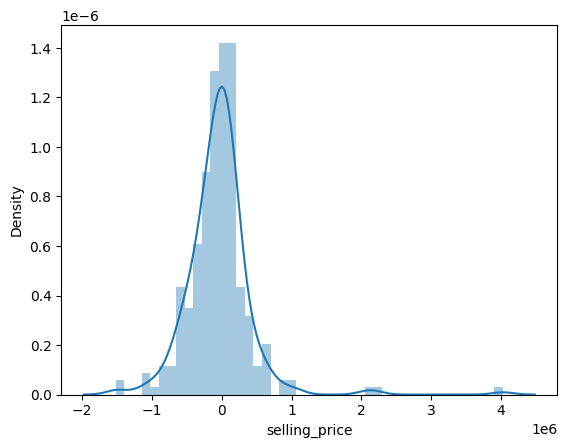

In [86]:
sns.distplot(y_test-y_pred)

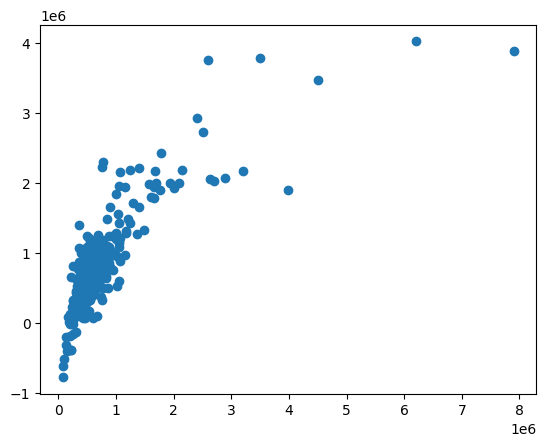

In [88]:
#best fitline
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)